(-5.0, 5.0)

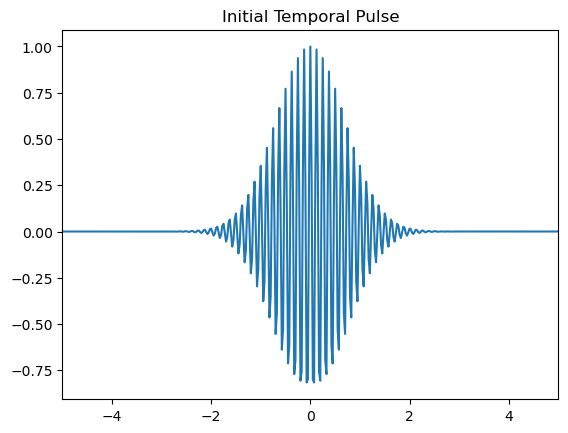

In [1]:
# Spectral Broadening via Self-Phase Modulation (Replicating Wolfram Demonstration)
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq

# --- Parameters as in Wolfram notebook ---
dt = 0.025                  # Time step (arbitrary units)
num_points = 2**12          # Number of sampling points
t = np.linspace(-num_points/2, num_points/2 - 1, num_points) * dt  # Time axis
omega = 50                  # Carrier frequency in Hz (cos(50 t))

E_initial = np.exp(-t**2)*np.cos(omega*t)

# plotting the temporal pulse initially
plt.plot(t, E_initial)
plt.title("Initial Temporal Pulse")
plt.xlim(-5, 5)

<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_8200/106178340.py:32: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel("$\omega$ (rad/s)")


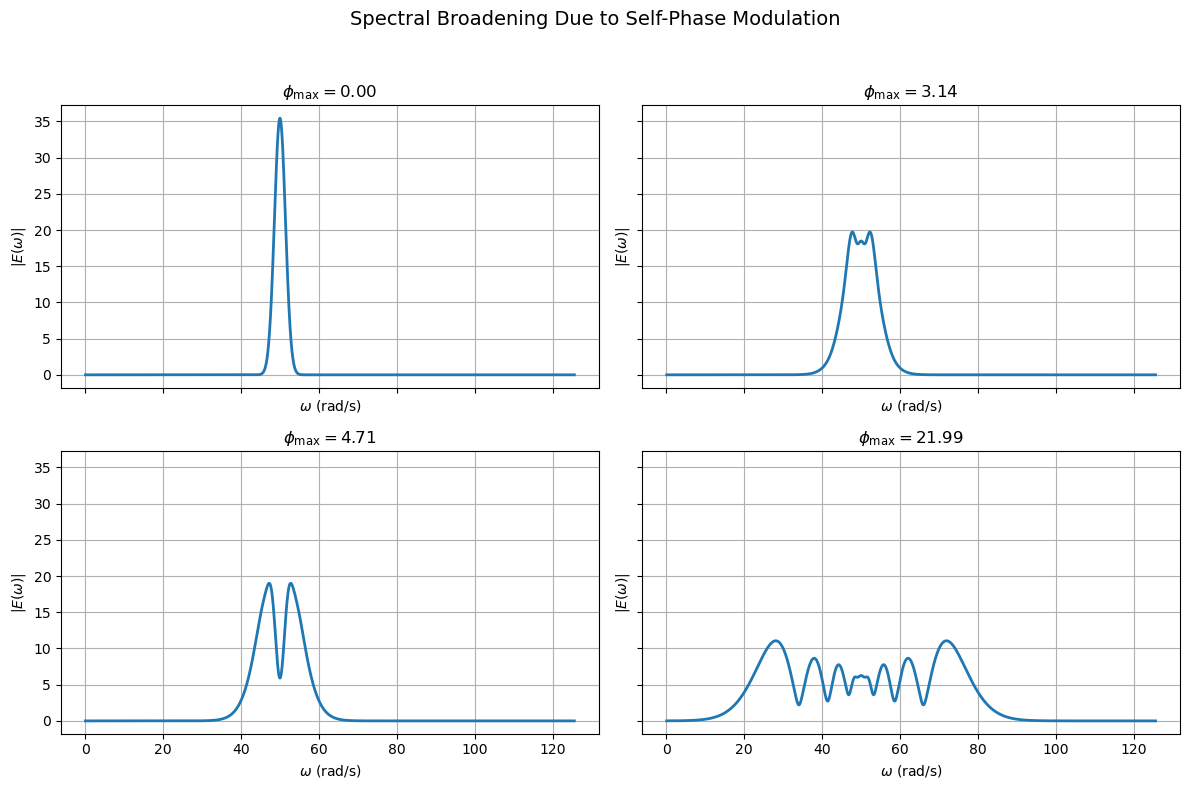

In [2]:

# Define list of nonlinear phase shifts φ_max
phi_max_list = [0, np.pi, 3*np.pi/2, 7*np.pi]

# --- Create 4-panel subplot to show spectral broadening ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, phi_max in enumerate(phi_max_list):
    # Envelope and nonlinear phase shift
    envelope = np.exp(-t**2)
    nonlinear_phase = phi_max * np.exp(-2 * t**2)

    # Output field after SPM: modulated Gaussian with chirped phase
    E_out = envelope * np.cos(omega * t + nonlinear_phase)

    # Compute spectrum using FFT
    E_fft = fft(E_out)
    freqs = fftfreq(num_points, dt)

    # Extract positive frequency components only
    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask] * 2* np.pi
    spectrum_mag = np.abs(E_fft[pos_mask])
    # spectrum_mag /= np.max(spectrum_mag)  # Normalize for comparison
    # Normalization off for comparing intensity redistribution with broadening

    # Plot on corresponding subplot
    ax = axes[idx]
    ax.plot(freqs_pos, spectrum_mag, linewidth=2)
    ax.set_title(rf"$\phi_{{\max}} = {phi_max:.2f}$", fontsize=12)
    ax.grid(True)
    ax.set_xlabel("$\omega$ (rad/s)")
    ax.set_ylabel(r"$|E(\omega)|$")

# Finalize layout
plt.suptitle("Spectral Broadening Due to Self-Phase Modulation", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


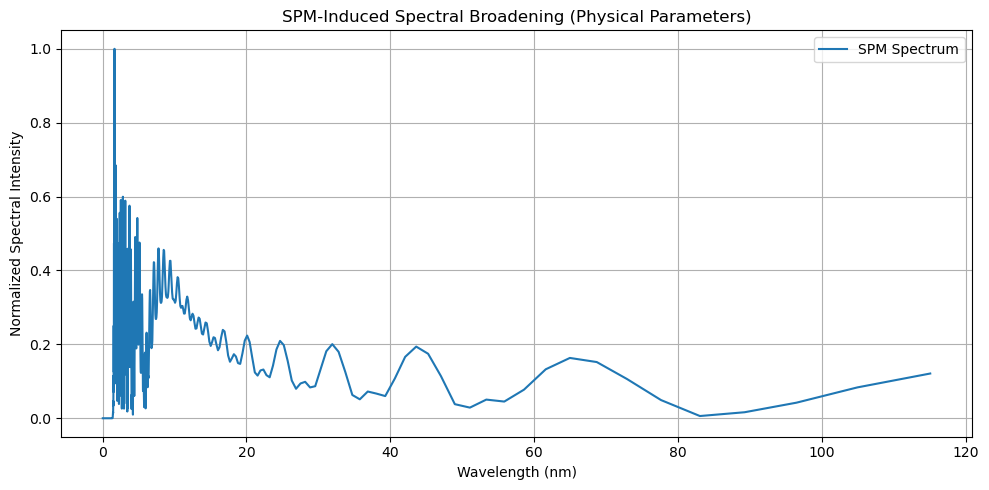

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftshift, fftfreq

# --- Physical Constants ---
c = 3e8  # speed of light (m/s)

# --- Laser Parameters ---
lambda0 = 800e-9                    # central wavelength (800 nm)
tau_fwhm = 1.75e-15                  # pulse duration (FWHM) in seconds
pulse_energy = 2350e-3/3e3          # pulse energy in joules: 2350 mW/3 kHz = approx 800 micro-J/pulse
beam_waist = 10e-6            

# --- Material Parameters (BK7 example) ---
n0 = 1.51                    # linear refractive index
n2 = 2.4e-20                 # nonlinear refractive index (m^2/W)
L = 6e-3                    # propagation length in m

# --- Derived Quantities ---
tau0 = tau_fwhm / (2 * np.sqrt(2 * np.log(2)))  # Gaussian std dev
omega0 = 2 * np.pi * c / lambda0                # angular frequency

# Peak intensity assuming Gaussian spatial and temporal profile
I0 = 2 * pulse_energy / (np.pi * beam_waist**2 * tau_fwhm)

# Maximum nonlinear phase shift
phi_max = (2 * np.pi / lambda0) * n2 * L * I0

# --- Time domain setup ---
num_points = 2**16
t_max = 5 * tau_fwhm
t = np.linspace(-t_max, t_max, num_points)
dt = t[1] - t[0]

# Time-domain Gaussian pulse
envelope = np.exp(-t**2 / (2 * tau0**2))
E_in = envelope * np.cos(omega0 * t)

# Nonlinear phase modulation
phi_nl = phi_max * np.exp(-t**2 / tau0**2)
E_out = envelope * np.cos(omega0 * t + phi_nl)

# --- Frequency domain ---
E_fft = fftshift(fft(E_out))
freq = fftshift(fftfreq(num_points, dt))
spectrum = np.abs(E_fft)
spectrum /= np.max(spectrum)

# Convert to wavelength axis for display
freq_positive = freq[freq > 0]
spectrum_positive = spectrum[freq > 0]
wavelength = c / (omega0 + 2 * np.pi * freq_positive)

# Plot spectrum
plt.figure(figsize=(10, 5))
plt.plot(wavelength * 1e9, spectrum_positive, label='SPM Spectrum')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Spectral Intensity")
plt.title("SPM-Induced Spectral Broadening (Physical Parameters)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
